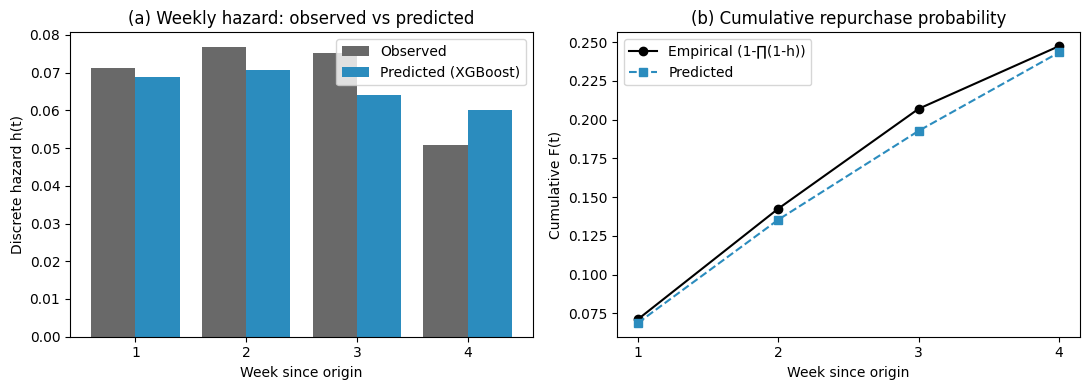

(a) 실제 hazard: [0.0712 0.0768 0.0751 0.0509]
(a) 예측 hazard: [0.0689 0.0706 0.0641 0.06  ]
(b) 실제 F: [0.0712 0.1426 0.207  0.2474]
(b) 예측 F: [0.0689 0.1354 0.1927 0.2433]


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

DATA = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model\weekly_curve_test.csv'
df = pd.read_csv(DATA)

N = 4
weeks = np.arange(1, N+1)

# ---- 절단본 필터: 이미 재구매한 이후 주차 행 제거 ----
# 생존 조건: 아직 재구매 안 했거나(event=0), 재구매했어도 그 주차 이하(week <= week_of_repurchase)
alive = (df['event'] == 0) | (df['week'] <= df['week_of_repurchase'])
tr = df[alive].copy()
# 절단본의 실제 y: 그 주에 처음 재구매했는가
tr['y'] = ((tr['event'] == 1) & (tr['week'] == tr['week_of_repurchase'])).astype(int)

# ---- (a) 주차별 hazard: 실제 vs 예측 (둘 다 절단본 = 같은 분모) ----
obs_h  = tr.groupby('week')['y'].mean().reindex(weeks).values
pred_h = tr.groupby('week')['h'].mean().reindex(weeks).values

# ---- (b) 누적 F: 전체 그리드 기준 ----
cust = df.drop_duplicates(['Customer ID','origin'])
obs_F  = np.array([((cust['event']==1) & (cust['week_of_repurchase']<=t)).mean() for t in weeks])
pred_F = df.groupby('week')['F'].mean().reindex(weeks).values

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# (a)
ax[0].bar(weeks-0.2, obs_h,  0.4, label='Observed', color='dimgray')
ax[0].bar(weeks+0.2, pred_h, 0.4, label='Predicted (XGBoost)', color='#2b8cbe')
ax[0].set_title('(a) Weekly hazard: observed vs predicted')
ax[0].set_xlabel('Week since origin'); ax[0].set_ylabel('Discrete hazard h(t)')
ax[0].set_xticks(weeks); ax[0].legend()

# (b)
ax[1].plot(weeks, obs_F,  'ko-', label='Empirical (1-∏(1-h))')
ax[1].plot(weeks, pred_F, 's--', color='#2b8cbe', label='Predicted')
ax[1].set_title('(b) Cumulative repurchase probability')
ax[1].set_xlabel('Week since origin'); ax[1].set_ylabel('Cumulative F(t)')
ax[1].set_xticks(weeks); ax[1].legend()

plt.tight_layout()
plt.savefig('fig_hazard_cumF.png', dpi=150)
plt.show()

# 검증 출력
print('(a) 실제 hazard:', obs_h.round(4))
print('(a) 예측 hazard:', pred_h.round(4))
print('(b) 실제 F:', obs_F.round(4))
print('(b) 예측 F:', pred_F.round(4))

C:\Users\rladp\AppData\Local\Temp\ipykernel_33204\3714538437.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lift = c.groupby('decile')['event'].mean() / base                # 십분위별 lift


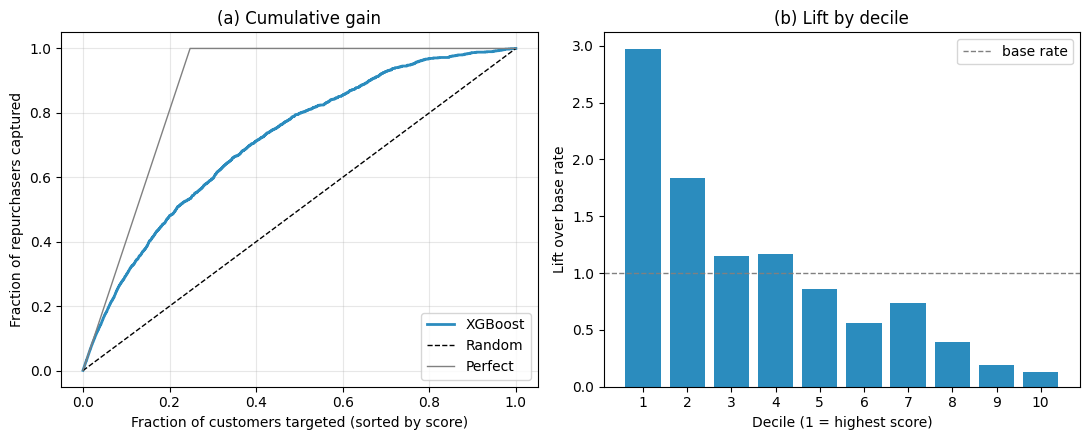

상위 10% lift: 2.97 배
상위 20% 재구매자 포착률: 0.481


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

DATA = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model\weekly_curve_test.csv'
df = pd.read_csv(DATA)

# 고객 단위 4주 최종 (F = 4주 누적확률, event = 실제 재구매)
c = df[df['week'] == 4][['Customer ID', 'F', 'event']].copy()
c = c.sort_values('F', ascending=False).reset_index(drop=True)   # 점수 높은 순
n = len(c)
base = c['event'].mean()                                          # 전체 재구매율

# ---- (a) Cumulative gain ----
c['cum_captured'] = c['event'].cumsum() / c['event'].sum()        # 포착한 재구매자 비율
x = np.arange(1, n+1) / n                                         # 타겟한 고객 비율
# perfect: 재구매자를 먼저 다 잡는 이상선
perfect = np.minimum(np.arange(1, n+1) / c['event'].sum(), 1.0)

# ---- (b) Lift by decile ----
c['decile'] = pd.qcut(c['F'].rank(method='first', ascending=False), 10, labels=range(1, 11))
lift = c.groupby('decile')['event'].mean() / base                # 십분위별 lift

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

# (a) Cumulative gain
ax[0].plot(x, c['cum_captured'], color='#2b8cbe', lw=2, label='XGBoost')
ax[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax[0].plot(x, perfect, color='gray', lw=1, label='Perfect')
ax[0].set_title('(a) Cumulative gain')
ax[0].set_xlabel('Fraction of customers targeted (sorted by score)')
ax[0].set_ylabel('Fraction of repurchasers captured')
ax[0].legend(); ax[0].grid(alpha=.3)

# (b) Lift by decile
ax[1].bar(range(1, 11), lift.values, color='#2b8cbe')
ax[1].axhline(1.0, color='gray', ls='--', lw=1, label='base rate')
ax[1].set_title('(b) Lift by decile')
ax[1].set_xlabel('Decile (1 = highest score)'); ax[1].set_ylabel('Lift over base rate')
ax[1].set_xticks(range(1, 11)); ax[1].legend()

plt.tight_layout()
plt.savefig('fig_gain_lift.png', dpi=150)
plt.show()

# 검증
print('상위 10% lift:', round(lift.loc[1], 2), '배')
print('상위 20% 재구매자 포착률:', round(c['cum_captured'].iloc[int(n*0.2)], 3))

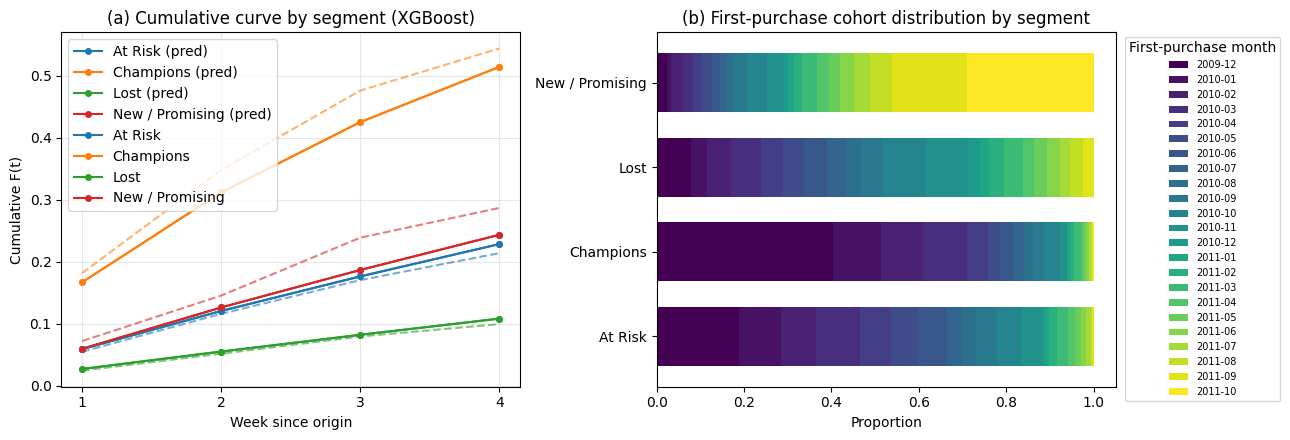

4-week cumulative F by segment:
Segment
At Risk            0.2283
Champions          0.5141
Lost               0.1082
New / Promising    0.2434
Name: F, dtype: float64

cohort match missing: 0 / 5619


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

weeks = [1,2,3,4]
colors = {'At Risk':'tab:blue','Champions':'tab:orange','Lost':'tab:green','New / Promising':'tab:red'}

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))


# (a) 세그먼트별 누적곡선: 실제 vs 예측
cust_seg = df[df['week']==4][['Customer ID','Segment','event','week_of_repurchase']].drop_duplicates()

for seg, g_pred in df.groupby('Segment'):
    # 예측 (실선)
    pred = g_pred.groupby('week')['F'].mean().reindex(weeks)
    ax[0].plot(weeks, pred.values, 'o-', ms=4, color=colors.get(seg), label=f'{seg} (pred)')
    # 실제 (점선)
    gc = cust_seg[cust_seg['Segment']==seg]
    obs = [((gc['event']==1)&(gc['week_of_repurchase']<=t)).mean() for t in weeks]
    ax[0].plot(weeks, obs, '--', color=colors.get(seg), alpha=0.6)
# ── (left) Cumulative curve by segment ──
for seg, g in df.groupby('Segment'):
    curve = g.groupby('week')['F'].mean().reindex(weeks)
    ax[0].plot(weeks, curve.values, 'o-', ms=4, label=seg, color=colors.get(seg))
ax[0].set_xticks(weeks); ax[0].set_xlabel('Week since origin'); ax[0].set_ylabel('Cumulative F(t)')
ax[0].set_title('(a) Cumulative curve by segment (XGBoost)'); ax[0].legend(); ax[0].grid(alpha=.3)

# ── (right) First-purchase cohort distribution by segment ──
cust = df[df['week']==4][['Customer ID','Segment']].merge(coh, on='Customer ID', how='left')
ct = pd.crosstab(cust['Segment'], cust['cohort'], normalize='index')
ct = ct[sorted(ct.columns)]
ct.plot(kind='barh', stacked=True, ax=ax[1], colormap='viridis', width=0.7)
ax[1].set_xlabel('Proportion'); ax[1].set_ylabel('')
ax[1].set_title('(b) First-purchase cohort distribution by segment')
ax[1].legend(title='First-purchase month', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(BASE + r'\fig_segment_cohort.png', dpi=150, bbox_inches='tight')
plt.show()

# validation
print('4-week cumulative F by segment:'); print(df[df['week']==4].groupby('Segment')['F'].mean().round(4))
print('\ncohort match missing:', cust['cohort'].isna().sum(), '/', len(cust))

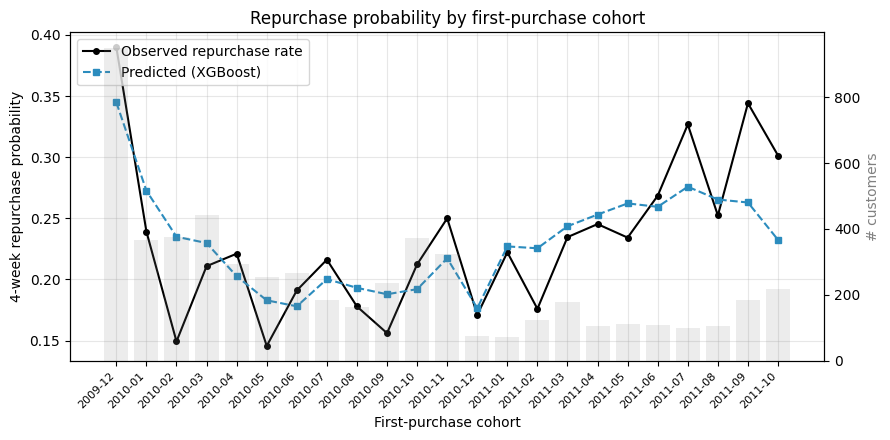

 cohort   n     실제     예측
2009-12 949 0.3899 0.3448
2010-01 368 0.2391 0.2726
2010-02 375 0.1493 0.2349
2010-03 441 0.2109 0.2298
2010-04 294 0.2211 0.2027
2010-05 254 0.1457 0.1830
2010-06 267 0.1910 0.1781
2010-07 185 0.2162 0.2003
2010-08 163 0.1779 0.1932
2010-09 237 0.1561 0.1879
2010-10 372 0.2124 0.1921
2010-11 324 0.2500 0.2173
2010-12  76 0.1711 0.1766
2011-01  72 0.2222 0.2270
2011-02 125 0.1760 0.2255
2011-03 179 0.2346 0.2435
2011-04 106 0.2453 0.2531
2011-05 111 0.2342 0.2622
2011-06 108 0.2685 0.2594
2011-07 101 0.3267 0.2758
2011-08 107 0.2523 0.2654
2011-09 186 0.3441 0.2630
2011-10 219 0.3014 0.2324

코호트 순서 vs 실제 재구매율 상관: 0.345


In [6]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'
df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')
df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

# 고객 4주 최종 (F=예측 재구매확률, event=실제)
cust = (df[df['week']==4][['Customer ID','F','event']]
        .merge(coh, on='Customer ID', how='left'))

# 코호트별 집계
g = (cust.groupby('cohort')
     .agg(n=('event','size'), 실제=('event','mean'), 예측=('F','mean'))
     .reset_index().sort_values('cohort'))
g = g[g['n'] >= 20]   # 표본 너무 적은 코호트 제외 (노이즈 방지)

fig, ax1 = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(g))

# 재구매확률 (좌축, 선)
ax1.plot(x, g['실제'], 'ko-', ms=4, label='Observed repurchase rate')
ax1.plot(x, g['예측'], 's--', color='#2b8cbe', ms=4, label='Predicted (XGBoost)')
ax1.set_ylabel('4-week repurchase probability')
ax1.set_xlabel('First-purchase cohort')
ax1.set_xticks(x); ax1.set_xticklabels(g['cohort'], rotation=45, ha='right', fontsize=8)
ax1.legend(loc='upper left'); ax1.grid(alpha=.3)

# 고객 수 (우축, 막대)
ax2 = ax1.twinx()
ax2.bar(x, g['n'], alpha=0.15, color='gray')
ax2.set_ylabel('# customers', color='gray')

ax1.set_title('Repurchase probability by first-purchase cohort')
plt.tight_layout(); plt.savefig(BASE + r'\fig_cohort_repurchase.png', dpi=150); plt.show()

# 상관계수
r = np.corrcoef(np.arange(len(g)), g['실제'])[0,1]
print(g.round(4).to_string(index=False))
print(f'\n코호트 순서 vs 실제 재구매율 상관: {r:.3f}')


[Pearson correlation]
           tenure  observed  predicted
tenure      1.000    -0.345     -0.147
observed   -0.345     1.000      0.798
predicted  -0.147     0.798      1.000


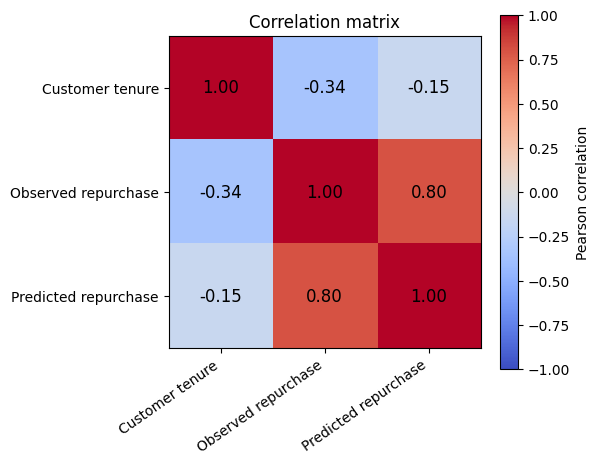

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = r'C:\Users\rladp\Desktop\ACK_2_Cohort_Transformer\data\model'

df = pd.read_csv(BASE + r'\weekly_curve_test.csv')
coh = pd.read_csv(BASE + r'\first_cohort.csv')

df['Customer ID'] = df['Customer ID'].astype(str)
coh['Customer ID'] = coh['Customer ID'].astype(str)

# ------------------------------------------------------------
# 1. 고객별 4주 결과
# ------------------------------------------------------------

cust = (
    df[df['week'] == 4][['Customer ID', 'F', 'event']]
    .merge(coh, on='Customer ID', how='left')
)

# ------------------------------------------------------------
# 2. 최초구매 코호트별 집계
# ------------------------------------------------------------

g = (
    cust.groupby('cohort')
    .agg(
        n=('event', 'size'),
        observed=('event', 'mean'),
        predicted=('F', 'mean')
    )
    .reset_index()
)

g['cohort_date'] = pd.to_datetime(g['cohort'].astype(str))

# 표본 작은 코호트 제외
g = g[g['n'] >= 20].copy()

# ------------------------------------------------------------
# 3. 첫 구매 후 경과기간
#    값이 클수록 오래된 코호트
# ------------------------------------------------------------

TEST_ORIGIN = pd.Timestamp('2011-10-31')

g['tenure'] = (
    (TEST_ORIGIN.year - g['cohort_date'].dt.year) * 12
    + (TEST_ORIGIN.month - g['cohort_date'].dt.month)
)

# ------------------------------------------------------------
# 4. Pearson correlation matrix
# ------------------------------------------------------------

cols = ['tenure', 'observed', 'predicted']
corr = g[cols].corr(method='pearson')

print('\n[Pearson correlation]')
print(corr.round(3))

# ------------------------------------------------------------
# 5. Correlation heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))

ax.set_xticklabels(
    ['Customer tenure', 'Observed repurchase', 'Predicted repurchase']
)
ax.set_yticklabels(
    ['Customer tenure', 'Observed repurchase', 'Predicted repurchase']
)

plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha='right'
)

# 숫자 표시
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(
            j, i,
            f'{corr.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=12
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Pearson correlation')

ax.set_title('Correlation matrix')

plt.tight_layout()
plt.show()